In [1]:
import os
import pandas as pd
import re

def clean_text(text):
    # Lowercase
    text = text.lower()
    # Remove multiple spaces and newlines
    text = re.sub(r'\s+', ' ', text)
    # Strip leading/trailing whitespace
    text = text.strip()
    return text

def load_folder(folder_path, label):
    data = []
    for filename in os.listdir(folder_path):
        if filename.endswith(".txt"):
            file_path = os.path.join(folder_path, filename)
            with open(file_path, 'r', encoding='utf-8', errors='ignore') as f:
                content = f.read()
                content = clean_text(content)
                if len(content) > 50:  # Filter out nearly-empty files
                    data.append({
                        'title': os.path.splitext(filename)[0],
                        'text': content,
                        'label': label
                    })
    return data

# Load both folders
human_data = load_folder('Dataset_worldPolitics/wiki_old_politics_dataset', label=0)
ai_data = load_folder('Dataset_worldPolitics/ai_politics_dataset', label=1)

# Combine and shuffle
import random
all_data = human_data + ai_data
random.shuffle(all_data)

# Create DataFrame
df = pd.DataFrame(all_data)

# Save to CSV
df.to_csv('political_wiki_human_ai_dataset.csv', index=False)

print("✅ Done! Dataset shape:", df.shape)
print(df['label'].value_counts())
df.head()


✅ Done! Dataset shape: (2860, 3)
label
1    1430
0    1430
Name: count, dtype: int64


,title,text,label
0,Saddam Hussein,**saddam hussein** **early life and political ...,1
1,Canada in NATO,canada has been a member of the north atlantic...,0
2,Indochina wars,**indochina wars** the term “indochina wars” e...,1
3,Standing NATO Maritime Group 2,standing nato maritime group 2 (snmg2) is a no...,0
4,9 November in German history,**9 november in german history** **9 november*...,1


Class Distribution:
label
1    1430
0    1430
Name: count, dtype: int64


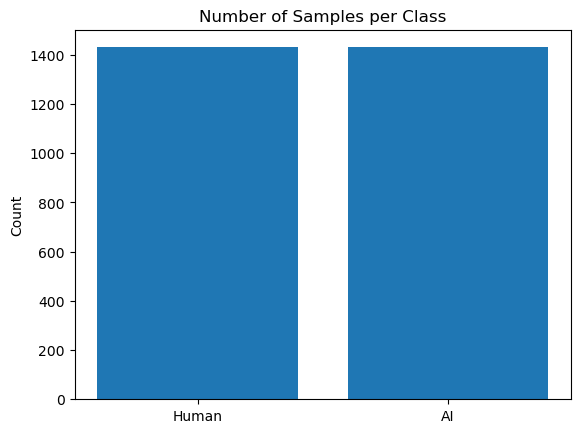

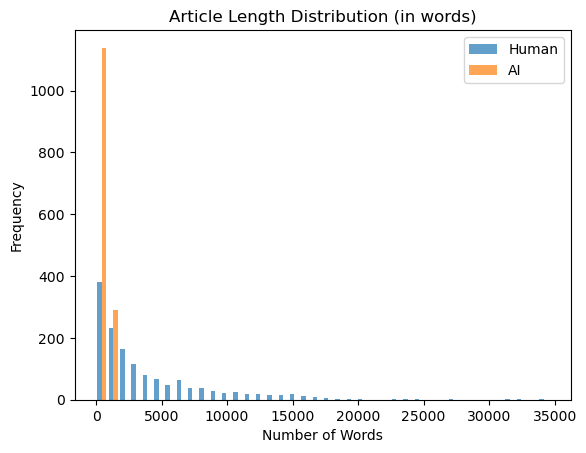

Text length stats (words):
        count         mean          std    min     25%     50%      75%  \
label                                                                     
0      1430.0  4069.003497  4735.064072    9.0  821.75  2245.0  5743.50   
1      1430.0   805.048252    86.051174  176.0  756.00   813.5   861.75   

           max  
label           
0      34597.0  
1       1099.0  

Top 20 words in Human-written texts:
[('the', 435182), ('of', 209433), ('and', 171141), ('in', 155562), ('to', 134275), ('a', 101988), ('was', 63461), ('s', 52367), ('that', 46338), ('on', 45635), ('as', 45538), ('for', 44204), ('by', 44003), ('with', 38278), ('were', 29355), ('from', 29029), ('his', 23655), ('at', 23482), ('war', 23180), ('he', 22924)]

Top 20 words in AI-generated texts:
[('the', 71390), ('and', 59512), ('of', 36822), ('in', 28113), ('to', 20554), ('a', 18663), ('s', 16283), ('as', 9297), ('for', 8144), ('war', 7740), ('political', 7556), ('with', 7181), ('by', 7049), ('on', 68

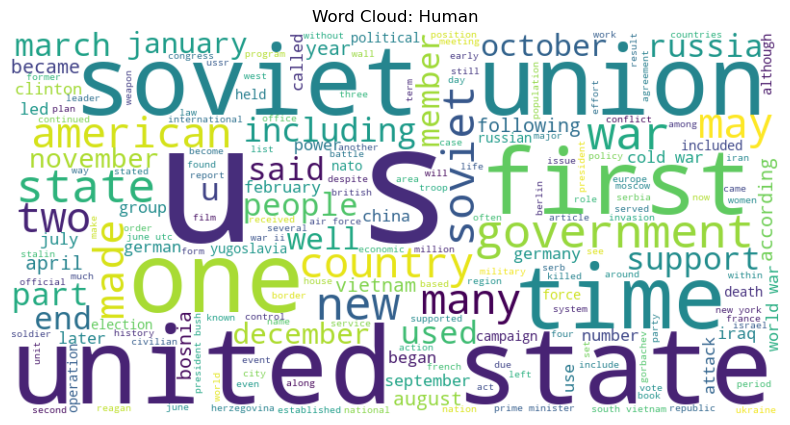

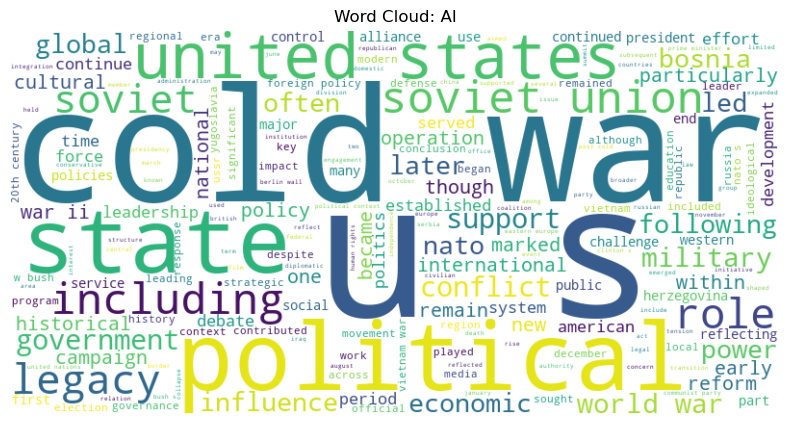

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

# Load your dataset
df = pd.read_csv('political_wiki_human_ai_dataset.csv')

# Class Distribution
print("Class Distribution:")
print(df['label'].value_counts())
plt.bar(['Human', 'AI'], df['label'].value_counts())
plt.title('Number of Samples per Class')
plt.ylabel('Count')
plt.show()

# Text Length Distribution
df['text_length'] = df['text'].apply(lambda x: len(x.split()))
plt.hist([df[df['label']==0]['text_length'], df[df['label']==1]['text_length']],
         label=['Human', 'AI'], bins=40, alpha=0.7)
plt.legend()
plt.title('Article Length Distribution (in words)')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.show()

print("Text length stats (words):")
print(df.groupby('label')['text_length'].describe())

# Most Common Words in Each Class
from collections import Counter
import re

def get_top_words(texts, n=20):
    words = []
    for text in texts:
        words += re.findall(r'\b\w+\b', text)
    most_common = Counter(words).most_common(n)
    return most_common

print("\nTop 20 words in Human-written texts:")
print(get_top_words(df[df['label']==0]['text']))

print("\nTop 20 words in AI-generated texts:")
print(get_top_words(df[df['label']==1]['text']))

# Example: Show some outliers (very short or very long articles)
print("\nShortest articles:")
print(df.nsmallest(5, 'text_length')[['title', 'text_length', 'label']])
print("\nLongest articles:")
print(df.nlargest(5, 'text_length')[['title', 'text_length', 'label']])

# Optional: Word cloud visualization
try:
    from wordcloud import WordCloud

    for label, label_name in zip([0,1], ['Human', 'AI']):
        text_blob = ' '.join(df[df['label']==label]['text'])
        wc = WordCloud(width=800, height=400, background_color='white').generate(text_blob)
        plt.figure(figsize=(10, 5))
        plt.imshow(wc, interpolation='bilinear')
        plt.axis('off')
        plt.title(f'Word Cloud: {label_name}')
        plt.show()
except ImportError:
    print("Install the 'wordcloud' package to see word clouds: pip install wordcloud")


In [5]:
!pip install wordcloud


   ---------------------------------------- 0.0/301.2 kB ? eta -:--:--
   ---------------------------------------- 0.0/301.2 kB ? eta -:--:--
   - -------------------------------------- 10.2/301.2 kB ? eta -:--:--
   -- ------------------------------------ 20.5/301.2 kB 162.5 kB/s eta 0:00:02
   ----- --------------------------------- 41.0/301.2 kB 279.3 kB/s eta 0:00:01
   ----------- --------------------------- 92.2/301.2 kB 521.8 kB/s eta 0:00:01
   ---------------------------------------- 301.2/301.2 kB 1.3 MB/s eta 0:00:00
